In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [3]:
df = pd.read_csv(r'housing.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  str    
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), str(1)
memory usage: 1.6 MB


In [5]:
df.size

206400

In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity', 'median_house_value'],
      dtype='str')

In [8]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


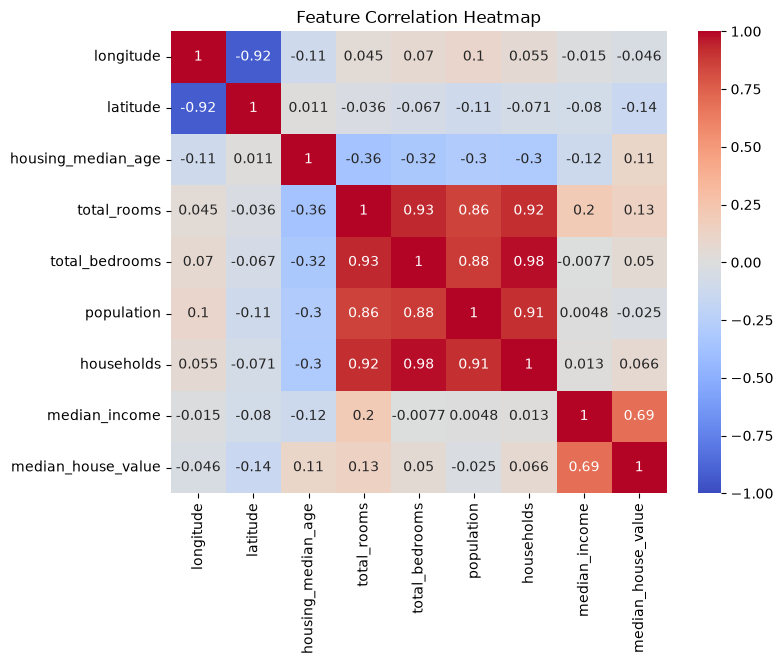

In [9]:
corr_matrix = df.drop(['ocean_proximity'],axis=1).corr()


# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title('Feature Correlation Heatmap')
plt.show()

(array([  36.,  841., 1628., 1984., 1878., 2221., 2153., 1618., 1591.,
        1208., 1075.,  694.,  567.,  672.,  435.,  317.,  244.,  235.,
         144., 1099.]),
 array([ 14999. ,  39249.1,  63499.2,  87749.3, 111999.4, 136249.5,
        160499.6, 184749.7, 208999.8, 233249.9, 257500. , 281750.1,
        306000.2, 330250.3, 354500.4, 378750.5, 403000.6, 427250.7,
        451500.8, 475750.9, 500001. ]),
 <BarContainer object of 20 artists>)

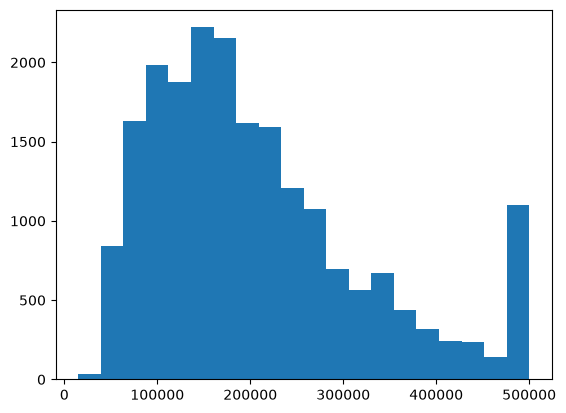

In [10]:
plt.hist(df['median_house_value'],bins=20,)
#

In [11]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


In [12]:
df.value_counts()

longitude  latitude  housing_median_age  total_rooms  total_bedrooms  population  households  median_income  ocean_proximity  median_house_value
-122.23    37.88     41                  880          129.0           322         126         8.3252         NEAR BAY         452600                1
-122.22    37.86     21                  7099         1106.0          2401        1138        8.3014         NEAR BAY         358500                1
-122.24    37.85     52                  1467         190.0           496         177         7.2574         NEAR BAY         352100                1
-122.25    37.85     52                  1274         235.0           558         219         5.6431         NEAR BAY         341300                1
                                         1627         280.0           565         259         3.8462         NEAR BAY         342200                1
                                                                                                         

In [13]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

In [14]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,False,False,True,False
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,False,False,True,False
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,False,False,True,False
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,False,False,True,False
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,False,False,True,False


In [15]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='str')

In [16]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())

In [17]:
df['ocean_proximity_INLAND'] = df['ocean_proximity_INLAND'].astype(int)
df['ocean_proximity_ISLAND'] = df['ocean_proximity_ISLAND'].astype(int)
df['ocean_proximity_NEAR BAY'] = df['ocean_proximity_NEAR BAY'].astype(int)
df['ocean_proximity_NEAR OCEAN'] = df['ocean_proximity_NEAR OCEAN'].astype(int)

In [18]:
from sklearn.model_selection import train_test_split
X = df.drop('median_house_value',axis=1)
y = df['median_house_value']
y = np.log1p(df['median_house_value'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [23]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
model_xg = xgb.XGBRegressor()
model_xg.fit(X_train, y_train)
y_pred = model_xg.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [24]:
r2

0.8368629783026568

In [26]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='str')

In [25]:
joblib.dump(model_xg,"model.pkl")

['model.pkl']